# **PART I**
## **Build, Train, and Test an LSTM with Time Series Data**

In [1]:
# Importing basic libraries
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
!pip install tensorflow

In [3]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [4]:
# For timeseries RNN LSTM NN
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

In [5]:
# Importing Keras : TimeseriesGenerator
# Produces time series batches used on training/testing the model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

#Import Keras: MinMaxScaler
# Used to preprocess (scale) the data
from sklearn.preprocessing import MinMaxScaler

## **Dataset : APPL (Apple Stock: 2022 - 2024)**

In [6]:
dir_path_dataset_1= 'APPLE_2022_2024_data.csv'

## **Loading Dataset**

In [7]:
df_ALL = pd.read_csv(dir_path_dataset_1)

In [8]:
df_ALL.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-04-26,162.250000,162.339996,156.720001,156.800003,155.028397,95623200
1,2022-04-27,155.910004,159.789993,155.380005,156.570007,154.800980,88063200
2,2022-04-28,159.250000,164.520004,158.929993,163.639999,161.791077,130216800
3,2022-04-29,161.839996,166.199997,157.250000,157.649994,155.868744,131747600
4,2022-05-02,156.710007,158.229996,153.270004,157.960007,156.175278,123055300


## **Brief EDA**

In [9]:
df_ALL.shape

(503, 7)

In [10]:
df_ALL.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [11]:
#Statistical Summary
df_ALL.describe()

,Open,High,Low,Close,Adj Close,Volume
count,503.000000,503.000000,503.000000,503.000000,503.000000,5.030000e+02
mean,165.201412,166.956581,163.619742,165.373300,164.591496,6.870596e+07
std,18.681449,18.362656,18.911069,18.643272,18.950564,2.418479e+07
min,126.010002,127.769997,124.169998,125.019997,124.166641,2.404830e+07
25%,148.884995,150.930000,147.264999,149.375000,148.143013,5.136640e+07
50%,168.490005,169.339996,166.899994,168.000000,167.515854,6.389620e+07
75%,180.379997,182.079994,178.440002,180.640007,180.048981,7.950650e+07
max,198.020004,199.619995,197.000000,198.110001,197.857529,1.826020e+08


## **Keeping Only "Close" (for Closing Price) and Filter Out All other Attributes**
Note: this project focuses only on the closing price

In [12]:
df = df_ALL.iloc[:,4:5]

In [13]:
df.head()

,Close
0,156.800003
1,156.570007
2,163.639999
3,157.649994
4,157.960007


<Axes: >

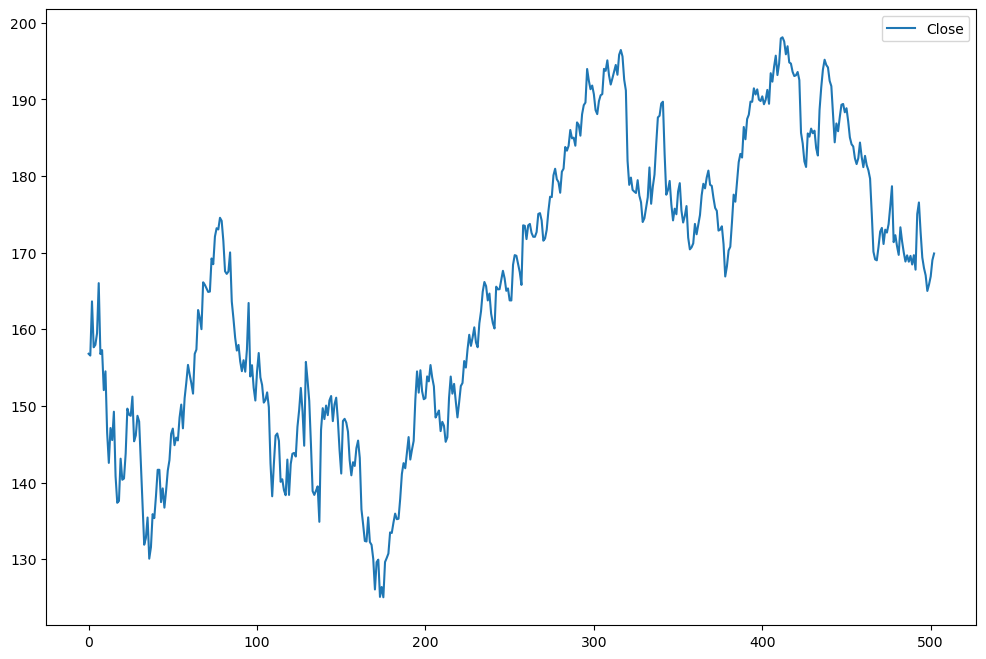

In [14]:
df.plot(figsize=(12,8))

## **Length of Input Time Series - Number of Input Time Steps**

In [15]:
# Setting the length of the input sequence
# i.e., the number of time series steps that are used to predict the future one
# Currently using 60 historical data points to predict the next one
# It means 60 consecutive closing prices will be used to predict the next one
length60 = 60

In [16]:
length60

60

## **Time Series Dataset: Train/test Split**

In [17]:
len(df)

503

In [18]:
# Set percentage of data used for testing

test_percent = 0.1

In [19]:
# Number of data points reserved for testing the model 
# 10% of the original dataset

len(df)*test_percent

50.300000000000004

## **Splitting Data into Train/Test**

In [20]:
# We need to find the length of the testing dataset (We have already done so above (about 50 data points for testing)

test_length = np.round(len(df)*test_percent)
test_length

50.0

In [21]:
# Testing data starts at this index

# test_start_index = int(len(df) - test_length)
split_index = int(len(df) - test_length)
split_index

453

In [22]:
# Creating seperate training/ testing datasets

# Training dataset : All the indices from start to split_index (excluding split_index)
data_train = df.iloc[: split_index]

#Testing dataset : All indices from split_index - length60 to the end of the dataframe
#split_index - length60 : Need the last 60 historical data points (belong to data_train) to predict the first data point of the data_test
data_test = df.iloc[split_index - length60 :]

In [23]:
data_train.head(5)

,Close
0,156.800003
1,156.570007
2,163.639999
3,157.649994
4,157.960007


In [24]:
data_train.tail()

,Close
448,189.410004
449,188.320007
450,188.850006
451,187.149994
452,185.039993


In [25]:
data_test.head(5)

,Close
393,189.710007
394,189.690002
395,191.449997
396,190.639999
397,191.309998


In [26]:
data_test.tail()

,Close
498,165.000000
499,165.839996
500,166.899994
501,169.020004
502,169.889999


## **Normalizing the Data (Scale into range [0,1]**

In [27]:
#Creating a MnMaxScaler to normalize the data
scaler = MinMaxScaler()

In [28]:
#Converting the data to floats
# ONLY scaling the training data- not the testing data

# Training the scaler to perform the normalization
scaler.fit(data_train)

MinMaxScaler()

In [29]:
#Normalizing the training dataset
normalized_train = scaler.transform(data_train)

#Normalizing the testing dataset
normalized_test = scaler.transform(data_test)

## **Creating TimeseriesGenerator for Training**

In [30]:
#TimeseriesGenerator : Generating time series batches for training/testing

#Set the length of the input sequence as length60 (like above)
#batch_size : Number of time series samples in each batch
#Sample: A single time series input that has 60 historical data points
batch_size32 = 32

# Creating a TimeseriesGeneerator for training: train_tsGenerator
# to produce time series batches used to train the model
# TimeseriesGenerator (inputs, outputs, length, batch_size)
train_tsGenerator60 = TimeseriesGenerator(normalized_train, normalized_train, length=length60, batch_size=batch_size32)

In [31]:
len(normalized_train)

453

In [32]:
len(train_tsGenerator60)

13

In [33]:
# What does the first batch look like?
X,y = train_tsGenerator60[0]

In [34]:
print(X)

[[[0.43480646]
  [0.43165971]
  [0.52838966]
  ...
  [0.3554522 ]
  [0.3833629 ]
  [0.41496795]]

 [[0.43165971]
  [0.52838966]
  [0.44643584]
  ...
  [0.3833629 ]
  [0.41496795]
  [0.39772879]]

 [[0.52838966]
  [0.44643584]
  [0.45067736]
  ...
  [0.41496795]
  [0.39772879]
  [0.3821316 ]]

 ...

 [[0.32412107]
  [0.31385974]
  [0.24107266]
  ...
  [0.49746896]
  [0.46367499]
  [0.44055277]]

 [[0.31385974]
  [0.24107266]
  [0.16568624]
  ...
  [0.46367499]
  [0.44055277]
  [0.45067736]]

 [[0.24107266]
  [0.16568624]
  [0.09385699]
  ...
  [0.44055277]
  [0.45067736]
  [0.42126145]]]


In [35]:
print(y)

[[0.39772879]
 [0.3821316 ]
 [0.36366134]
 [0.43466951]
 [0.44233147]
 [0.51292921]
 [0.49924745]
 [0.47872481]
 [0.56245732]
 [0.55807906]
 [0.55178556]
 [0.54521817]
 [0.5459023 ]
 [0.6050076 ]
 [0.59474628]
 [0.64413745]
 [0.65905052]
 [0.6568614 ]
 [0.67765773]
 [0.6721849 ]
 [0.636202  ]
 [0.58215909]
 [0.57750714]
 [0.58161171]
 [0.61581611]
 [0.52811597]
 [0.49746896]
 [0.46367499]
 [0.44055277]
 [0.45067736]
 [0.42126145]
 [0.40374881]]


# **Build, Train and Test Model**

## Building LSTM Model

In [36]:
#Setting number of features
#Feature: Attribute/Variable of the dataset - used as predictors

#Only using one feature: Close price
n_features = 1

In [37]:
# Defining the model
model = Sequential()

# Adding on LSTM layer
# This layer has 50 LSTM cells
# Activation function: ReLU
# return_sequences = True
# Multiple LSTM layers are made because layers are stacked
# Outputs = inputs of the next LSTM layer
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(length60, n_features)))

#Dropout layer
model.add(Dropout(0.2))

# Adding the 2nd LSTM layer
# return_sequences=True
# Multiple LSTM layers are made because layers are stacked
# Outputs = inputs of the next LSTM layer
model.add(LSTM(units=50, activation='relu', return_sequences=True))

#Dropout layer
model.add(Dropout(0.2))

#Adding the 3rd LSTM layer
model.add(LSTM(units=50, activation='relu'))

#Adding a FC layer for the final prediction
model.add(Dense(1))

C:\Users\sonam\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## **Compiling the model**

In [38]:
# Compile the model
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

## **Training (Fit) Model using fit_generator()**

In [39]:
# Training the model
# fit_generator does not work in this version of tensorflow, so I ave used model.fit()
model.fit(train_tsGenerator60, epochs=100)

Epoch 1/100


C:\Users\sonam\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - loss: 0.1975
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0480
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0162
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0199
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0231
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0206
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0162
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0134
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0127
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0154
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0158
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0103
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0132
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0149
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0107
E

## **Visualizing the model's performance after Training**

In [40]:
loss_history_keys = model.history.history.keys()

#model.history.history is a dict
# 'loss' : its key
# 'loss' : loss during training
loss_history_keys

dict_keys(['loss'])

<Axes: >

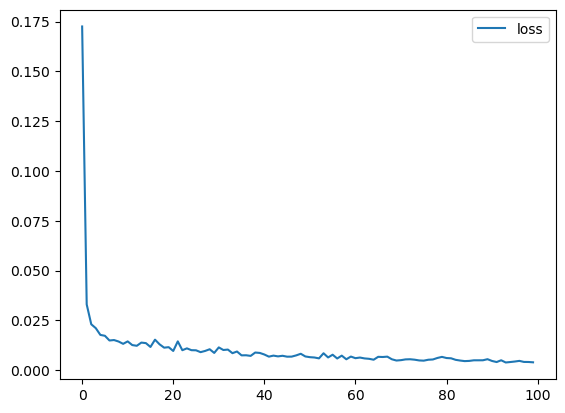

In [41]:
#Load the loss data (model.history.history) into a data frame
df_model_loss = pd.DataFrame(model.history.history)

#Visualize the loss data using DataFrame.plot()
df_model_loss.plot()

# **Prediction for Testing: Using TimeseriesGenerator**

## **Create TimeseriesGenerator for Testing**

In [42]:
# batch_size must be 1
batch_size1 = 1

# Create a TimeSeriesGenerator for testing: test_tsGenerator
test_tsGenerator60 = TimeseriesGenerator(normalized_test, normalized_test, length=length60, batch_size=batch_size1)

## **Predicting Future Data Points for Testing**

In [43]:
#model.predict_generator does not work with the latest version of tensorflow, so we use model.predict
normalized_prediction = model.predict(test_tsGenerator60)

C:\Users\sonam\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [44]:
#Prediction is a numpy 2D array with only one column

normalized_prediction

array([[0.8883228 ],
       [0.87840164],
       [0.86469   ],
       [0.84835666],
       [0.83158314],
       [0.8186828 ],
       [0.8144091 ],
       [0.81489205],
       [0.81553775],
       [0.8177915 ],
       [0.8191575 ],
       [0.8181303 ],
       [0.8133372 ],
       [0.7983415 ],
       [0.7699151 ],
       [0.7355291 ],
       [0.7009763 ],
       [0.67221284],
       [0.65510523],
       [0.65183467],
       [0.6567576 ],
       [0.66863704],
       [0.68325865],
       [0.6987627 ],
       [0.7156935 ],
       [0.7334832 ],
       [0.739525  ],
       [0.7352804 ],
       [0.7220386 ],
       [0.7026499 ],
       [0.6872601 ],
       [0.6757616 ],
       [0.6661571 ],
       [0.65667427],
       [0.64915067],
       [0.6430967 ],
       [0.63992816],
       [0.63791674],
       [0.6385009 ],
       [0.63842326],
       [0.6465259 ],
       [0.66251796],
       [0.6791595 ],
       [0.6872349 ],
       [0.68392146],
       [0.67087805],
       [0.64974934],
       [0.627

In [45]:
len(normalized_prediction)

50

In [46]:
# Converting normalized predictions back to the true values
prediction = scaler.inverse_transform(normalized_prediction)

In [47]:
# Flattening all the 2D array

# data_train = data_train.reshape((-1))
# data_test = data_test.reshape((-1))
# prediction = prediction.reshape((-1))

prediction_index = np.arange(393, 393 + len(prediction), step=1)

df_prediction = pd.DataFrame(data=prediction,index=prediction_index, columns=['Prediction'])

In [48]:
df_prediction

,Prediction
393,189.947525
394,189.222366
395,188.220200
396,187.026398
397,185.800400
398,184.857513
399,184.545151
400,184.580460
401,184.627655
402,184.792374


## **Visualizing the Prediction**

<Axes: >

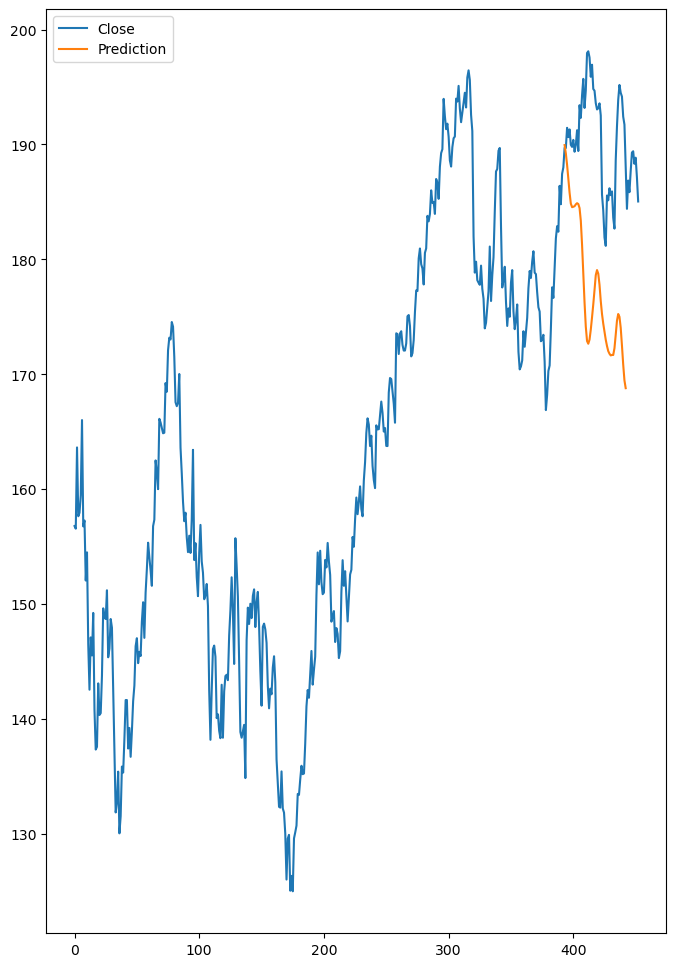

In [49]:
ax = data_train.plot()
df_prediction.plot(ax=ax, figsize=(8, 12))

# **Time Series Forecasting with LSTM**

## **Preprocess Full Input Dataset**

In [50]:
# Still using MinMaxScaler to normalize the full input dataset df

full_scaler = MinMaxScaler()
normalized_full_data = full_scaler.fit_transform(df)

## **Creating a TimeseriesGenerator for Forecasting**

In [51]:
# Number of time steps of the input time series
# Still use length60
length60

60

In [52]:
# Creating a timeseries Generator for forcasting
forecast_tsGenerator = TimeseriesGenerator(normalized_full_data, normalized_full_data, length=length60, batch_size=batch_size32)

# **Build, Compile and Fit LSTM model for Forecasting**

In [53]:
# Train/Fit LSTM model
# We do not validate, we only FORECAST

model.fit(forecast_tsGenerator, epochs= 100)

Epoch 1/100
 1/14 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0025

C:\Users\sonam\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0038
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0039
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0051
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0040
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0047
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0038
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0042
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0036
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0046
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0049
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0045
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0037
Epoch 13/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0054
Epoch 14/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0047
Epoch 15/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0052
E

## **Time Series Forecast Using LSTM NN**

In [54]:
forecast = []

# Set periods with time span of forecasting
# Lets forecast for the next 107 business days 
periods = 107

first_eval_batch = normalized_full_data[-length60:]
current_batch = first_eval_batch.reshape((1, length60, n_features))

for i in range(periods):
    # get prediction 1 time stamp ahead ([0] is for grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]
    
    # store prediction
    forecast.append(current_pred)
    
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━

## **Inverse to Tansform Normalized Data Back into True Values**

In [55]:
# Convert normalized predictions back to the original scale
forecast = full_scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()

forecast

array([169.12663, 170.424  , 171.56981, 172.65544, 173.69347, 174.67456,
       175.57166, 176.36638, 177.05557, 177.64111, 178.11192, 178.4883 ,
       178.8049 , 179.08656, 179.35338, 179.62354, 179.91174, 180.2283 ,
       180.57872, 180.96411, 181.38174, 181.8259 , 182.28598, 182.75565,
       183.22823, 183.69568, 184.15106, 184.5887 , 185.00407, 185.39403,
       185.7557 , 186.08594, 186.38463, 186.65392, 186.89708, 187.11804,
       187.32083, 187.50916, 187.68614, 187.85425, 188.0152 , 188.17   ,
       188.31909, 188.46248, 188.59991, 188.73094, 188.85521, 188.97234,
       189.08221, 189.18481, 189.28035, 189.3691 , 189.45155, 189.5282 ,
       189.5996 , 189.66624, 189.72867, 189.7873 , 189.84245, 189.89449,
       189.94366, 189.99034, 190.03465, 190.07674, 190.11667, 190.15454,
       190.19035, 190.22417, 190.25606, 190.28606, 190.3143 , 190.34079,
       190.36568, 190.38902, 190.41093, 190.43152, 190.45087, 190.46909,
       190.4862 , 190.50235, 190.51756, 190.53188, 

In [56]:
df

,Close
0,156.800003
1,156.570007
2,163.639999
3,157.649994
4,157.960007
...,...
498,165.000000
499,165.839996
500,166.899994
501,169.020004


## **Creating a new timestamp index with pandas**

In [57]:
# Calculate forecast index
# Set forecast index starting immediately after the last index of historical data
last_index = df.index[-1]  # Get the last index from the historical dataset
forecast_index = range(last_index + 1, last_index + 1 + len(forecast))  # Generate aligned indices


In [58]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index, columns=['Forecast'])

In [59]:
forecast_df

,Forecast
503,169.126633
504,170.423996
505,171.569809
506,172.655441
507,173.693466
...,...
605,190.697388
606,190.701157
607,190.704712
608,190.708084


# **Plotting the forecast**

<Axes: >

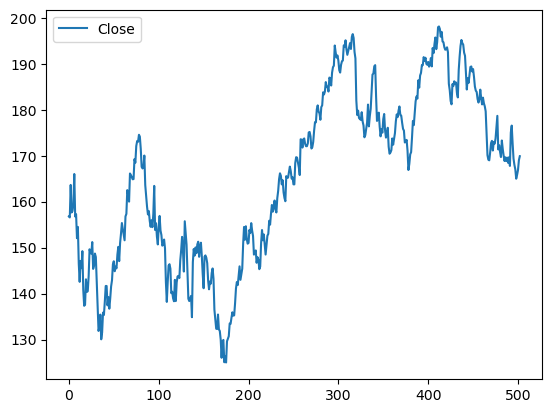

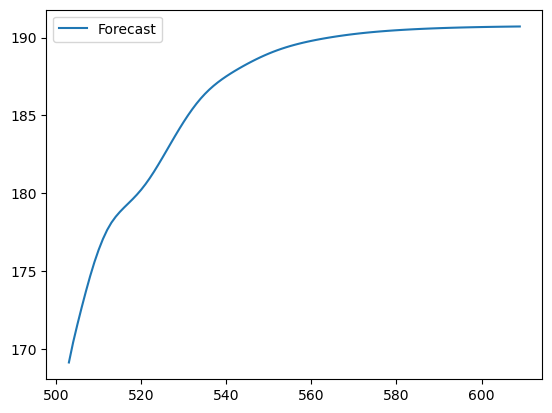

In [60]:
df.plot()
forecast_df.plot()

## **Joining Pandas Plots**

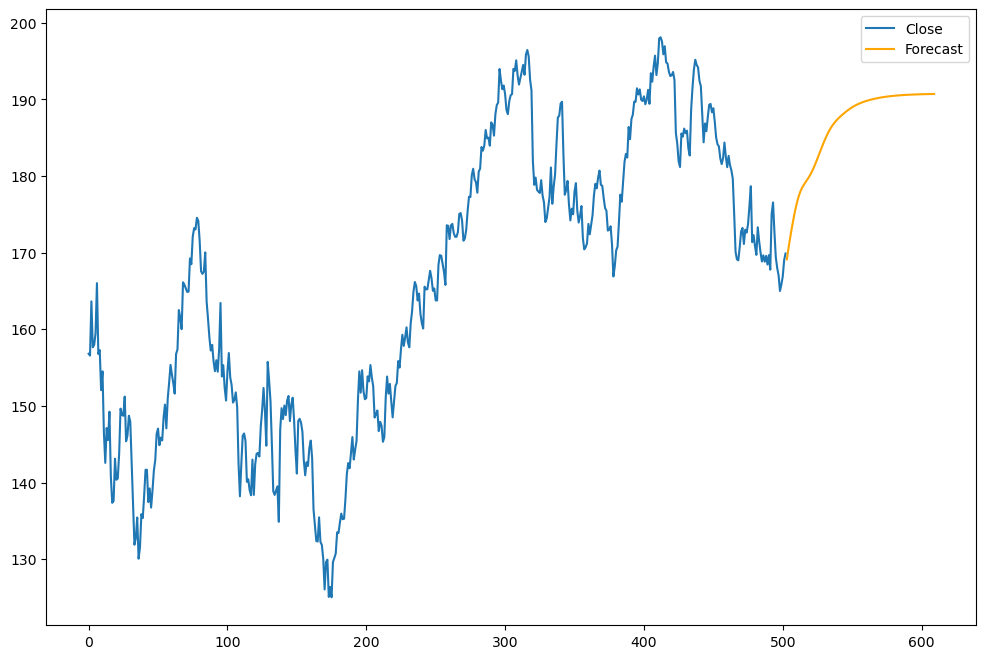

In [61]:
# Create DataFrame for the forecast
forecast_df = pd.DataFrame({'Forecast': forecast}, index=forecast_index)

# Plot historical and forecast data
ax = df['Close'].plot(figsize=(12, 8), label='Close')  # Historical data
forecast_df.plot(ax=ax, label='Forecast', color='orange')  # Forecasted data
plt.legend()
plt.show()

         Date        Open        High         Low       Close   Adj Close  \
0  2022-04-26  162.250000  162.339996  156.720001  156.800003  155.028397   
1  2022-04-27  155.910004  159.789993  155.380005  156.570007  154.800980   
2  2022-04-28  159.250000  164.520004  158.929993  163.639999  161.791077   
3  2022-04-29  161.839996  166.199997  157.250000  157.649994  155.868744   
4  2022-05-02  156.710007  158.229996  153.270004  157.960007  156.175278   

      Volume  
0   95623200  
1   88063200  
2  130216800  
3  131747600  
4  123055300  


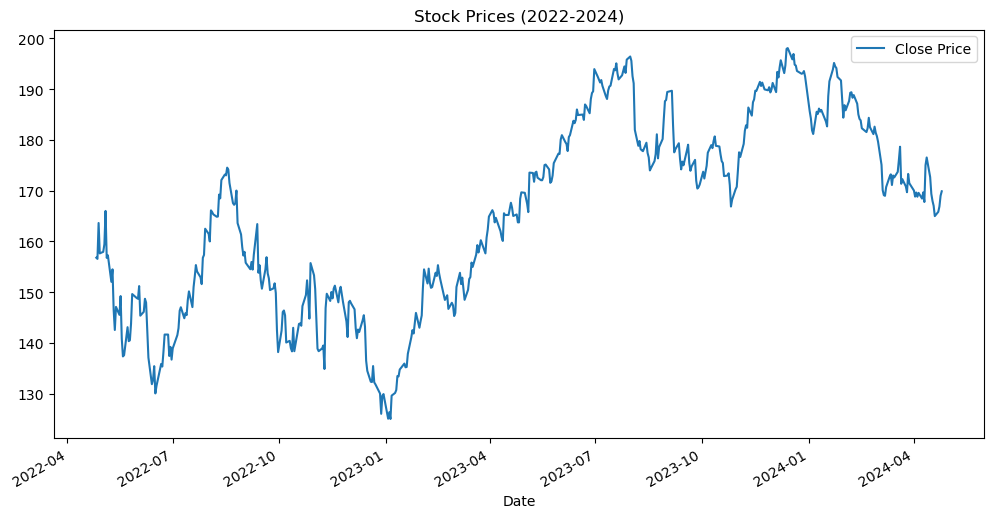

In [62]:
dir_path_dataset = 'APPLE_2022_2024_data.csv'
df = pd.read_csv(dir_path_dataset)

# Inspecting the dataset
print(df.head())

# Filtering relevant columns (only 'Date' and 'Close')
df = df.loc[:, ['Date', 'Close']]

# Converting 'Date' to datetime format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Filtering data for specific time period (if required)
start_date = '2022-04-26'  # Adjust to your dataset's date range
end_date = '2024-04-25'
df_filtered = df.loc[start_date:end_date]

# Plotting the filtered data
df_filtered['Close'].plot(figsize=(12, 6), title='Stock Prices (2022-2024)', label='Close Price')
plt.legend()
plt.show()


In [63]:
forecast_df['Forecast'].values

array([169.12663, 170.424  , 171.56981, 172.65544, 173.69347, 174.67456,
       175.57166, 176.36638, 177.05557, 177.64111, 178.11192, 178.4883 ,
       178.8049 , 179.08656, 179.35338, 179.62354, 179.91174, 180.2283 ,
       180.57872, 180.96411, 181.38174, 181.8259 , 182.28598, 182.75565,
       183.22823, 183.69568, 184.15106, 184.5887 , 185.00407, 185.39403,
       185.7557 , 186.08594, 186.38463, 186.65392, 186.89708, 187.11804,
       187.32083, 187.50916, 187.68614, 187.85425, 188.0152 , 188.17   ,
       188.31909, 188.46248, 188.59991, 188.73094, 188.85521, 188.97234,
       189.08221, 189.18481, 189.28035, 189.3691 , 189.45155, 189.5282 ,
       189.5996 , 189.66624, 189.72867, 189.7873 , 189.84245, 189.89449,
       189.94366, 189.99034, 190.03465, 190.07674, 190.11667, 190.15454,
       190.19035, 190.22417, 190.25606, 190.28606, 190.3143 , 190.34079,
       190.36568, 190.38902, 190.41093, 190.43152, 190.45087, 190.46909,
       190.4862 , 190.50235, 190.51756, 190.53188, 

In [64]:
forecast_df['Forecast']

503    169.126633
504    170.423996
505    171.569809
506    172.655441
507    173.693466
          ...    
605    190.697388
606    190.701157
607    190.704712
608    190.708084
609    190.711227
Name: Forecast, Length: 107, dtype: float32

            Close    Forecast
2024-09-17    NaN  190.697388
2024-09-18    NaN  190.701157
2024-09-19    NaN  190.704712
2024-09-20    NaN  190.708084
2024-09-23    NaN  190.711227


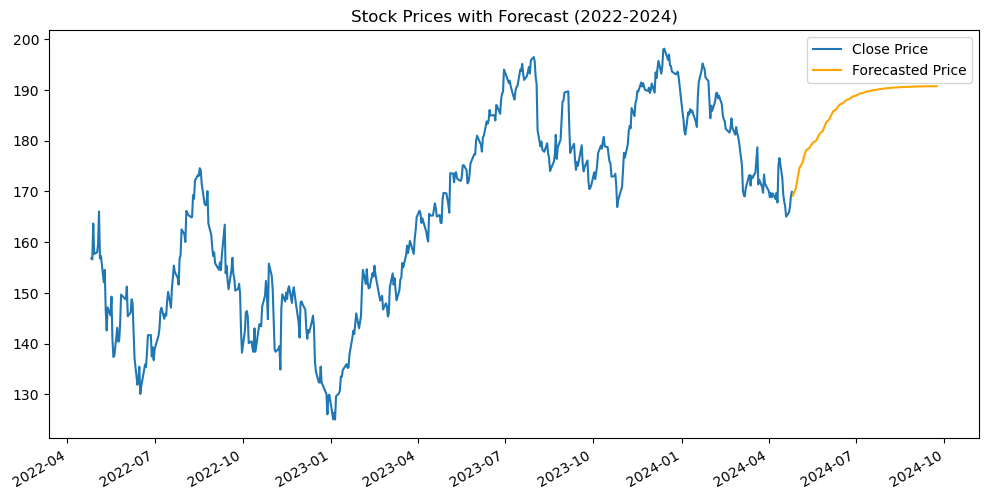

In [65]:
# Extending df_filtered to include forecasted dates
future_dates = pd.date_range(start=df_filtered.index[-1] + pd.Timedelta(days=1), periods=len(forecast), freq='B')
df_extended = df_filtered.reindex(df_filtered.index.union(future_dates))

# Adding the Forecast column
df_extended['Forecast'] = None  # Initialize a blank Forecast column
df_extended.loc[future_dates, 'Forecast'] = forecast  # Adding forecasted values to the new dates

# Inspect the result
print(df_extended.tail())

# Plot the data
ax = df_extended['Close'].plot(figsize=(12, 6), label='Close Price')  # Historical prices
df_extended['Forecast'].plot(ax=ax, label='Forecasted Price', color='orange')  # Forecasted values
plt.legend()
plt.title("Stock Prices with Forecast (2022-2024)")
plt.show()
